<a href="https://colab.research.google.com/github/fyp12027-tech/Lidar/blob/main/Crack_Detection%20/Crack_Detection_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="Tj7SuarAynUVDY0Q0M20")
project = rf.workspace("oyyee").project("all-type-crack-dataset")
version = project.version(3)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 49.4 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to all-type-crack-dataset-3 in yolov8:: 100%|██████████| 1346/1346 [00:00<00:00, 6219.87it/s]


In [ ]:
import os
print(dataset.location) # This tells you exactly where the folder is
print(os.listdir(dataset.location)) # This shows you the train/test/valid folders

/content/all-type-crack-dataset-3
['README.roboflow.txt', 'test', 'train', 'README.dataset.txt', 'data.yaml', 'valid']


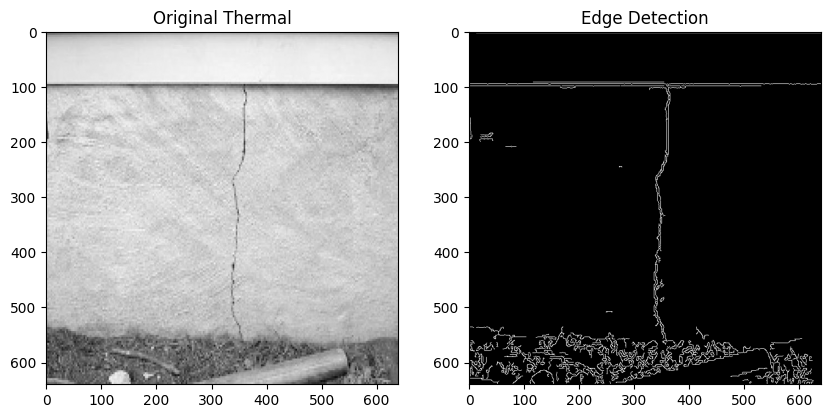

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os

# 1. Get the path to one image from your downloaded Roboflow folder
# (Change the folder name if yours is slightly different)
image_dir = '/content/all-type-crack-dataset-3/train/images/'
image_files = os.listdir(image_dir)
img_path = os.path.join(image_dir, image_files[0])

# 2. Load the image
image = cv2.imread(img_path)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) # Convert to grayscale

# 3. Apply Gaussian Blur (removes thermal noise)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# 4. Canny Edge Detection
# The numbers 50 and 150 are 'thresholds'. You can tweak them!
edges = cv2.Canny(blurred, 50, 150)

# 5. Show the results
plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.imshow(gray, cmap='gray'); plt.title('Original Thermal')
plt.subplot(1,2,2); plt.imshow(edges, cmap='gray'); plt.title('Edge Detection')
plt.show()

In [ ]:
!pip install ultralytics
from ultralytics import YOLO

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.9 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# Load a pre-trained "Nano" model (small and fast for students)
model = YOLO('yolov8n.pt')

# Train the model
results = model.train(
    data='/content/all-type-crack-dataset-3/data.yaml',
    epochs=25,      # How many times the AI looks at the whole dataset
    imgsz=640,      # Image size
    plots=True      # Generates charts for your FYP report
)

Ultralytics 8.4.36 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/all-type-crack-dataset-3/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10

In [ ]:
# 1. Load your BEST model that you just finished training
best_model = YOLO('/content/runs/detect/train/weights/best.pt')

# 2. Predict on the test images
results = best_model.predict(source='/content/all-type-crack-dataset-3/test/images', save=True)

# 3. Go to the sidebar: runs -> detect -> predict
# Double click an image there to see the boxes!


image 1/26 /content/all-type-crack-dataset-3/test/images/corrosion-cracks-11-3_jpg.rf.088b77ed12af27122e8fef58b0316f87.jpg: 640x640 1 corrosion crack, 8.2ms
image 2/26 /content/all-type-crack-dataset-3/test/images/crazing-crack-5_jpg.rf.80acc5f5f07a721d2ae30b18eaf239cd.jpg: 640x640 (no detections), 7.2ms
image 3/26 /content/all-type-crack-dataset-3/test/images/diagona-crack-3_jpg.rf.884973c0c74c345a9d3de1e521786b15.jpg: 640x640 (no detections), 7.2ms
image 4/26 /content/all-type-crack-dataset-3/test/images/drying-shrinkage-cracks-6-3_jpg.rf.5c0ed3c7d2b03c29e87c8cb2a936b835.jpg: 640x640 (no detections), 7.2ms
image 5/26 /content/all-type-crack-dataset-3/test/images/expansion-cracks-12-2_jpg.rf.9b5fd156f3d868bef62b660ab2efce62.jpg: 640x640 1 expansion crack, 1 hair line crack, 7.2ms
image 6/26 /content/all-type-crack-dataset-3/test/images/flexural-crack-3_jpg.rf.2a17548770ea7c835248cb9f6a871ead.jpg: 640x640 1 flexural crack, 7.4ms
image 7/26 /content/all-type-crack-dataset-3/test/images

In [ ]:
# Use your newly trained model on a test image
my_model = YOLO('/content/runs/detect/train/weights/best.pt')

# Run prediction
results = my_model.predict(source='/content/all-type-crack-dataset-3/test/images', save=True)

# This will save the images with boxes drawn around the cracks in the 'runs/detect/predict' folder!


image 1/26 /content/all-type-crack-dataset-3/test/images/corrosion-cracks-11-3_jpg.rf.088b77ed12af27122e8fef58b0316f87.jpg: 640x640 1 corrosion crack, 7.2ms
image 2/26 /content/all-type-crack-dataset-3/test/images/crazing-crack-5_jpg.rf.80acc5f5f07a721d2ae30b18eaf239cd.jpg: 640x640 (no detections), 7.2ms
image 3/26 /content/all-type-crack-dataset-3/test/images/diagona-crack-3_jpg.rf.884973c0c74c345a9d3de1e521786b15.jpg: 640x640 (no detections), 7.2ms
image 4/26 /content/all-type-crack-dataset-3/test/images/drying-shrinkage-cracks-6-3_jpg.rf.5c0ed3c7d2b03c29e87c8cb2a936b835.jpg: 640x640 (no detections), 7.2ms
image 5/26 /content/all-type-crack-dataset-3/test/images/expansion-cracks-12-2_jpg.rf.9b5fd156f3d868bef62b660ab2efce62.jpg: 640x640 1 expansion crack, 1 hair line crack, 7.2ms
image 6/26 /content/all-type-crack-dataset-3/test/images/flexural-crack-3_jpg.rf.2a17548770ea7c835248cb9f6a871ead.jpg: 640x640 1 flexural crack, 7.2ms
image 7/26 /content/all-type-crack-dataset-3/test/images